<a href="https://colab.research.google.com/github/SaymaSJ/3-DOF-Cobot--Dissertation/blob/main/ROI_Payback_%2B_Cycle_Time_vs_Speed_Cap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

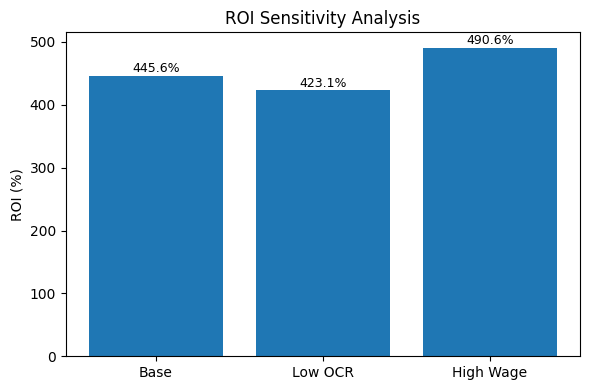

ROI summary table:


,Scenario,hours_year,elec_cost_year,labour_saved_year,markdown_saved_year,opex_year,net_benefit_year,payback_years,roi_percent
0,Base,2400,57.6,16200.0,1800.0,177.6,17822.4,0.22,445.6
1,Low OCR,2400,57.6,16200.0,900.0,177.6,16922.4,0.24,423.1
2,High Wage,2400,57.6,18000.0,1800.0,177.6,19622.4,0.20,490.6


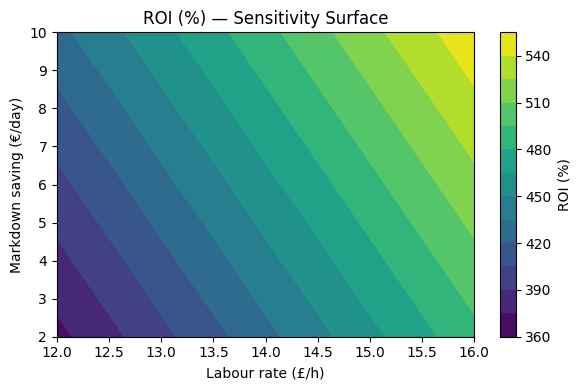

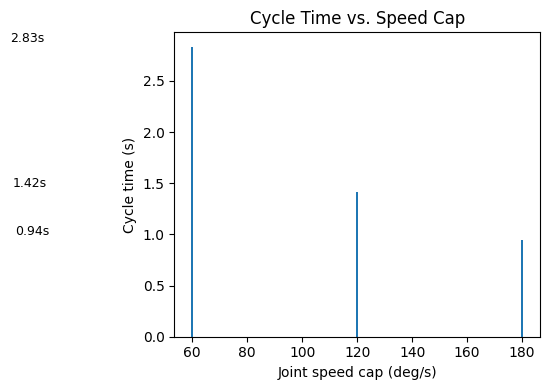

Cycle-time summary:


,speed_cap_deg_per_s,cycle_time_s
0,60,2.833
1,120,1.417
2,180,0.944



Dissertation Figures Generated on 2025-09-19.

Economic Evaluation (Base):
- Net annual benefit: £17,822.4
- Payback: 0.22 years
- ROI: 445.6%

Sensitivity:
- Low OCR scenario (markdown £/day=3): ROI 423.1%
- High wage (£15/h): ROI 490.6%

Cycle Time vs Speed Cap:
- Tested caps: [np.int64(60), np.int64(120), np.int64(180)] deg/s
- Cycle times (s): [np.float64(2.833), np.float64(1.417), np.float64(0.944)]

Saved files: 
 - /content/roi_summary.csv 
 - /content/roi_sensitivity.png 
 - /content/roi_surface.csv 
 - /content/roi_surface.png 
 - /content/cycle_time_vs_speed.csv 
 - /content/cycle_time_vs_speed.png 
 - /content/figures_summary.txt


In [ ]:
# ================================
# 3-DOF Cobot — Dissertation Figures
# ROI / Payback + Cycle Time vs Speed Cap
# Google Colab-ready (pure Python)
# ================================

import math, itertools, datetime as dt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------
# 1) ROI / Payback
# ----------------
def roi_payback(
    capex=4000.0,
    elec_per_hour_kwh=0.08, tariff=0.30,            # ~£0.024/h electricity
    maint_per_year=120.0,
    hours_per_day=8, days_per_week=6, weeks_per_year=50,
    labour_rate_per_hour=13.5, labour_offset_fte=0.5,  # half FTE saved
    markdown_saving_per_day=6.0                       # £ saved/day via earlier markdown/disposal
):
    hours_year = hours_per_day*days_per_week*weeks_per_year
    elec_cost_year = hours_year*elec_per_hour_kwh*tariff
    labour_saved_year = hours_year*labour_rate_per_hour*labour_offset_fte
    markdown_saved_year = markdown_saving_per_day*days_per_week*weeks_per_year
    opex_year = elec_cost_year + maint_per_year
    net_benefit_year = labour_saved_year + markdown_saved_year - opex_year
    payback_years = capex / max(net_benefit_year, 1e-9)
    roi_pct = (net_benefit_year / capex) * 100
    return {
        "hours_year": hours_year,
        "elec_cost_year": round(elec_cost_year,2),
        "labour_saved_year": round(labour_saved_year,2),
        "markdown_saved_year": round(markdown_saved_year,2),
        "opex_year": round(opex_year,2),
        "net_benefit_year": round(net_benefit_year,2),
        "payback_years": round(payback_years,2),
        "roi_percent": round(roi_pct,1)
    }

# Base + simple sensitivities (match your methodology)
base = roi_payback()
sens_low_ocr = roi_payback(markdown_saving_per_day=3.0)  # worse OCR→lower saving
sens_high_wage = roi_payback(labour_rate_per_hour=15.0)

df_roi = pd.DataFrame([
    {"Scenario":"Base", **base},
    {"Scenario":"Low OCR", **sens_low_ocr},
    {"Scenario":"High Wage", **sens_high_wage},
])

# Save table
df_roi.to_csv("/content/roi_summary.csv", index=False)

# Plot ROI (%) by scenario
plt.figure(figsize=(6,4))
plt.bar(df_roi["Scenario"], df_roi["roi_percent"])
plt.ylabel("ROI (%)")
plt.title("ROI Sensitivity Analysis")
for i,v in enumerate(df_roi["roi_percent"]):
    plt.text(i, v+1, f"{v:.1f}%", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("/content/roi_sensitivity.png", dpi=240)
plt.show()

print("ROI summary table:")
display(df_roi)

# -------------------------------
# 2) ROI Surface (optional, quick)
# -------------------------------
# Explore ROI over a grid of labour rate & markdown savings (for a heatmap-like view)
labour_grid = np.linspace(12.0, 16.0, 9)         # £/h
markdown_grid = np.linspace(2.0, 10.0, 9)        # £/day
rows = []
for w in labour_grid:
    for m in markdown_grid:
        out = roi_payback(labour_rate_per_hour=w, markdown_saving_per_day=m)
        rows.append({"labour_rate":w, "markdown_saving_per_day":m, **out})
df_surf = pd.DataFrame(rows)
df_surf.to_csv("/content/roi_surface.csv", index=False)

# Simple contour-like plot (no seaborn, per instructions)
Z = df_surf.pivot_table(index="markdown_saving_per_day", columns="labour_rate", values="roi_percent")
X, Y = np.meshgrid(Z.columns.values, Z.index.values)
plt.figure(figsize=(6,4))
cp = plt.contourf(X, Y, Z.values, levels=12)
plt.xlabel("Labour rate (£/h)")
plt.ylabel("Markdown saving (€/day)")
plt.title("ROI (%) — Sensitivity Surface")
plt.colorbar(cp, label="ROI (%)")
plt.tight_layout()
plt.savefig("/content/roi_surface.png", dpi=240)
plt.show()

# -------------------------------------------
# 3) Cycle Time vs Speed Cap (P2P trapezoids)
# -------------------------------------------
# Matches the MATLAB approach you used: time per segment = max(|Δq_j|)/speed_cap

deg = math.pi/180.0
# Example joint waypoints (rad) — tune to your real picks/places
q_home  = np.array([60, 70, 60])*deg
q_pick  = np.array([50, 45, 40])*deg
q_view  = np.array([40, 30, 30])*deg
q_place = np.array([10, 60,-20])*deg

way_q = np.vstack([q_home, q_pick, q_view, q_place, q_home])  # N x 3
seg_dq = np.abs(np.diff(way_q, axis=0))                       # (N-1) x 3
seg_max = seg_dq.max(axis=1)                                  # (N-1,)

speed_caps_deg = np.array([60, 120, 180])                     # deg/s test points
speed_caps = speed_caps_deg*deg                               # rad/s

def cycle_time_for_cap(wcap):
    # Sum of segment times using max joint delta / speed_cap
    return float((seg_max / wcap).sum())

cycle_times = np.array([cycle_time_for_cap(c) for c in speed_caps])

df_ct = pd.DataFrame({
    "speed_cap_deg_per_s": speed_caps_deg,
    "cycle_time_s": np.round(cycle_times, 3)
})
df_ct.to_csv("/content/cycle_time_vs_speed.csv", index=False)

plt.figure(figsize=(6,4))
plt.bar(df_ct["speed_cap_deg_per_s"], df_ct["cycle_time_s"])
plt.xlabel("Joint speed cap (deg/s)")
plt.ylabel("Cycle time (s)")
plt.title("Cycle Time vs. Speed Cap")
for i,(x,y) in enumerate(zip(df_ct["speed_cap_deg_per_s"], df_ct["cycle_time_s"])):
    plt.text(i, y+0.02, f"{y:.2f}s", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("/content/cycle_time_vs_speed.png", dpi=240)
plt.show()

print("Cycle-time summary:")
display(df_ct)

# -----------------------------
# 4) Export a one-paragraph blurb
# -----------------------------
summary = f"""
Dissertation Figures Generated on {dt.date.today().isoformat()}.

Economic Evaluation (Base):
- Net annual benefit: £{base['net_benefit_year']:,}
- Payback: {base['payback_years']} years
- ROI: {base['roi_percent']}%

Sensitivity:
- Low OCR scenario (markdown £/day=3): ROI {sens_low_ocr['roi_percent']}%
- High wage (£15/h): ROI {sens_high_wage['roi_percent']}%

Cycle Time vs Speed Cap:
- Tested caps: {list(speed_caps_deg)} deg/s
- Cycle times (s): {list(np.round(cycle_times,3))}
"""
with open("/content/figures_summary.txt","w") as f:
    f.write(summary)

print(summary)
print("Saved files:",
      "\n - /content/roi_summary.csv",
      "\n - /content/roi_sensitivity.png",
      "\n - /content/roi_surface.csv",
      "\n - /content/roi_surface.png",
      "\n - /content/cycle_time_vs_speed.csv",
      "\n - /content/cycle_time_vs_speed.png",
      "\n - /content/figures_summary.txt")
